# **Module 2: Mathematical Foundations for Machine Learning**

### **Prepared by: Hum Nath Bhandari, Department of Mathematics, RWU**

### **Course**: MATH 355/COMSC 415-Machine Learning 

### Notebook 9: Review of Descriptive Statistics and Statistical Inference





### **Overview**

In this notebook we will dicuss about descriptive statistics that comprise concepts, terms, measures, and tools that help to describe, show, and summarize the data in a meaningful way. When analysing data, such as the price of flats renting per year, it is possible to use both descriptive and inferential statistics in order to analyze the results and draw some conclusions. We will discuss basic concepts, terms and procedures, like mean, median, variance, correlation, etc., to explore, describe and summarize the given set of data.


In the later part, we will discuss about making inference on population based on sample. We will explore the relationship between sample parameters and population parameters and propose some methods to assess the quality of parameter estimates of a sample.




###  **Learning Outcomes**:

- Defining population and sample.
- Calculating sample mean, median, standard deviation, variance, etc.
- Data distributions

- Estimation and Central Limits Theorem.

- Calculating correlation coefficients, covarance coefficients.

- Point estimates.

- Sampling distribution of point estimates.
- Standard error of the point estimates.
- Bootstrapping.
- Confidence intervals.
- Confidence intervals using Bootstrapping.
- Hypothesis testing.



**Reference:** Chapter 3 of Textbook **Introduction to Data Science, A Python Approach to Concepts, Techniques, and Applicationsby  Laura  Igual  and  Santi  Segui  published  by  Springer;  ISBN  978-3-319-50016-4,  ISBN  978-3-319-50017-1**



##  Part I: Descriptive Statistical Methods(Exploratory Data Analysis)


### **Population and Sample**

Statistics is based on 2 main concepts:

- **Population**:  A population is a collection of all the objects or items (“units”) about which information is sought.

- **Sample**  A sample is a part of the population that is observed.

**Remarks**: Information in the sample can be considered as an initial evidence about what can potentially happen in the given population. 

### **Summarizing Data**: 

### 1. Sample Mean 

If you have a sample of $n$ values, $x_i$, the **sample mean** is the sum of the values divided by the number of values:

$$ \bar{x} = \frac{1}{n} \sum_i x_i$$

The **mean** is the most basic and important summary statistic. It describes the central tendency of a sample. **Median** is another popular measure of central tendency.  



In [1]:
#np.mean() from numpy  or df.mean() where df is pandas data frame.

### 2.  Sample Median

The statistical median is an order statistic that gives the **middle** value of a sample. It is a value more robust for the data which involves ouliers.

In [4]:
#np.median() or df.median() 

###  3.   Quantiles & Percentiles

Order the sample $\{ x_i \}$, then find $x_q$ so that it divides the data into parts where:

 - A fraction $q$ of the data values are less than or equal to $x_q$ and
 - The remaining fraction $(1 − q)$ are greater than $x_q$.

That value $x_q$ is the qth-quantile, or 100×qth percentile.


In [2]:
#np.quantile(array, 0.25, ....) # Q1  location 

#df.quantile(q=0.25, axis=0)  from pandas

###  4.  Measure Variability: Five Numbers Summary

**5-number summary**: $x_{min}, Q_1, Q_2, Q_3, x_{max}$, where $Q_1$ is the 25×pth percentile,
$Q_2$ is the 50×pth percentile and $Q_3$ is the 75×pth percentile.


In [4]:
#Pandas functions
#quartiles = np.percentile(data, [25, 50, 75])  # three measures  # double check.

#min, max = data.min(), data.max()

#df.describe() # provides six number summary (including mean) and other 


### 5.  Measure of Variability : Sample Variance and Sample Standard Deviation

Usually, mean is not a sufficient descriptor of the data, we can do a little better with two numbers: mean and **variance**:

$$ \sigma^2 = \frac{1}{n} \sum_i (x_i - \bar{x})^2 $$

**Variance** $\sigma^2$ describes the *spread* of data. The term $(x_i - \bar{x})$ is called the *deviation from the mean*, so variance is the mean squared deviation.

The square root of variance, $\sigma$, is called the **standard deviation**. We define standard deviation because variance is hard to interpret (in the case the units are grams, the variance is in grams squared). Let's get the basic statistics for our example data:





In [5]:
#Numpy functions

#np.var(), np.std()

#Pandas functions

#df.var(), df.std()

### 6. Data Distributions

Summarizing can be dangerous: very different data can be described by the same statistics. It must be validated by inspecting the data.

We can look at the **data distribution**, which describes how often (frequency) each value appears.



In [ ]:
#df.hist()  Creating histogram

### 7. Probability Mass Function (PMF)

We can normalize the frequencies of the histogram by dividing/normalizing by $n$, the number of samples. The normalized histogram is called **Probability Mass Function (PMF)**. We can use **density= 1** keyword to do this work.  

In [9]:

#df.hist(density= 1, bins=20)

### 8. Cumulative Distribution Function (CDF)

The **cumulative distribution function (CDF)** describes the probability that a real-valued random variable X with a given probability distribution will be found to have a value less than or equal to x. For our example, the CDFs will be:

In [11]:
#df.hist(density = True, histtype='step', cumulative = True)


### 9. Outliers

**Outliers** are data samples with a value that is far from the central tendency.

We can find outliers by:

 - Computing samples that are **far** from the median.
 - Computing samples whose value **exceeds the mean** by 2 or 3 standard deviations.


In [ ]:
# HW: Please write a python function which detects outliers in the given data and returns the data after removing outliers

 ### 10. Measuring Asymmetry.

**Skewness** is a statistic that measures the asymmetry of set of $n$ data samples $x_i$:

$$ sq = \frac{1}{n}\frac{\sum_i (x_i - \bar{x})^3}{\sigma^3} $$

- Negative deviation indicates that the distribution "skews left" (it extends farther to the left than to the right).

- Positive deviation indicates that the distribution "skews right" (it extends farther to the right than to the left).


**Pearson's median skewness coefficient** is a more robust alternative:

$$ sq = \frac{3(\bar{x} - median)}{\sigma }$$


In [16]:
def skewness(x):
    m= x.mean()
    s= x.std()
    res = 0.0
    for i in x:
        res+=(i-m)*(i-m)*(i-m)
    
        
    res/=(len(x)*s*s*s)
    
    return res

### 11. The Normal Distribution

The **normal, or Gaussian distribution** is the most used one because it describes a lot of phenomena and because it is amenable for analysis. 

Its CDF has no closed-form expression and its more common representation is the PDF:

$$ PDF(x) = \frac{1}{\sqrt{2 \pi \sigma^2}} \exp \left(-\frac{(x-\mu)^2}{2 \sigma^2} \right)$$


**Examples Distributions**:
    
* Measures of size of living tissue (length, height, skin area, weight);
* The length of inert appendages (hair, claws, nails, teeth) of biological specimens, in the direction of growth; presumably the thickness of tree bark also falls under this category;
* Certain physiological measurements, such as blood pressure of adult humans.


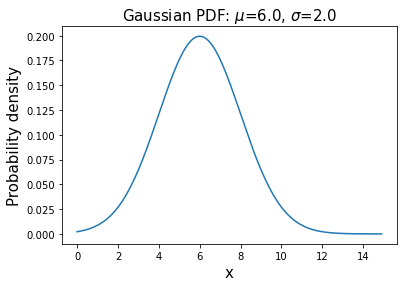

In [26]:
import numpy as np
import matplotlib.pyplot as plt
u=6 # mean
s=2 # standard deviation
x=np.arange(0,15,0.1)
y=(1/(np.sqrt(2*np.pi*s*s)))*np.exp(-(((x-u)**2)/(2*s*s)))
plt.plot(x,y,'-')
plt.title('Gaussian PDF: $\mu$=%.1f, $\sigma$=%.1f' % (u,s),fontsize=15)
plt.xlabel('x',fontsize=15)
plt.ylabel('Probability density',fontsize=15)
plt.show()

### 12.  Standard Score

$$ z_i = \frac{x_i - \mu}{\sigma}$$

This measure is dimensionless and its distribution has mean 0 and variance 1.

It inherits the "shape" of $X$: if it is normally distributed, so is $Z$. If $X$ is skewed, so is $Z$.


### 13. Covariance

**Covariance** is a measure of the tendency of two variables to vary together. 

If we have two series $X$ and $Y$ with $X=\{x_i\}$ and $Y=\{y_i\}$, and they vary together, their deviations $x_i - \mu_X$ and $y_i - \mu_Y$ tend to have the same sign.

If we multiply them together, the product is positive, when the deviations have the same sign, and negative, when they have the opposite sign. So adding up the products gives a measure of the tendency to vary together.

Covariance is the mean of the products:

$$ Cov(X,Y) = \frac{1}{n} \sum_{i=1}^n (x_i - \mu_X)*(y_i - \mu_Y), $$

where $n$ is the length of the two series.



In [14]:
def Cov(X, Y):
    
    dx =  [x - np.mean(X) for x in X]
    dy =  [y - np.mean(Y) for y in Y]
    return np.sum([x * y for x, y in zip(dx, dy)])/len(X)


### 14.  Pearson's Correlation 

Shell we take into account the variance? An alternative is to divide the deviations by $\sigma$, which yields standard scores, and compute the product of standard scores:

$$ p_i = \frac{(x_i - \mu_X)}{\sigma_X} \frac{(y_i - \mu_Y)}{\sigma_Y} $$
 
The mean of these products is:

$$ \rho = \frac{1}{n} \sum p_i = \frac{1}{n} \sum  \frac{(x_i - \mu_X)}{\sigma_X} \frac{(y_i - \mu_Y)}{\sigma_Y}  $$

Or we can rewrite $\rho$ by factoring out $\sigma_X$ and $\sigma_Y$:

$$ \rho = \frac{Cov(X,Y)}{\sigma_X \sigma_Y}$$

 
 
**Remarks**:  

- If $\rho < 0$, we say there is a negative correlation between the variables

- If $\rho > 0$, we say there is a positive correlation between the variables

- When $\rho = 0$, we cannot say that there is no relationship between the variables!

- Pearson's coefficient only measures **linear** correlations!

In [1]:
def Corr(X, Y):
    assert len(X) == len(Y)
    return Cov(X, Y) / np.prod([np.std(V) for V in [X, Y]])


In [20]:
#df.corr(method='pearson')

### 15.  Spearman’s Rank Correlation

Pearson’s correlation works well if the relationship between variables is linear and if the variables are roughly normal. But it is not robust in the presence of **outliers**.

Spearman’s rank correlation is an alternative that mitigates the effect of outliers and skewed distributions. To compute Spearman’s correlation, we have to compute the rank of each value, which is its index in the sorted sample. 

For example, in the sample {7, 1, 2, 5} the rank of the value 5 is 3, because it appears third if we sort the elements. 

Then, we compute the Pearson’s correlation, **but for the ranks**.


In [22]:
#scipy.stats.spearmanr(a, b=None, axis=0) from scipy library

## Part II: Statistical Inference


### 16. Central Limit Theorem

The normal distribution is also important, because it is involved in the Central Limit Theorem:

> Take the mean of $n$ random samples from ANY arbitrary distribution with a $well$ $defined$ standard deviation $\sigma$ and mean $\mu$. As $n$ gets bigger the **distribution of the sample mean** will always converge to a Gaussian (normal) distribution with mean $\mu$ and standard deviation $\frac{\sigma}{\sqrt{n}}$.

Colloquially speaking, the theorem states the distribution of an average tends to be normal, even when the distribution from which the average is computed is decidedly non-normal. This explains the ubiquity of the Gaussian distribution in science and statistics. 



#### **Understanding CLT**: 

The uniform distribution is obviously non-normal.  Let's call it the **parent distribution**.

To compute an average, two samples are drawn ($n=2$), at random, from the parent distribution and averaged. Then another sample of two is drawn and another value of the average computed.  This process is repeated, over and over, and averages of two are computed.  

Repeatedly taking more elements ($n = 3,4...$) from the parent distribution, and computing the averages, produces a normal probability density.

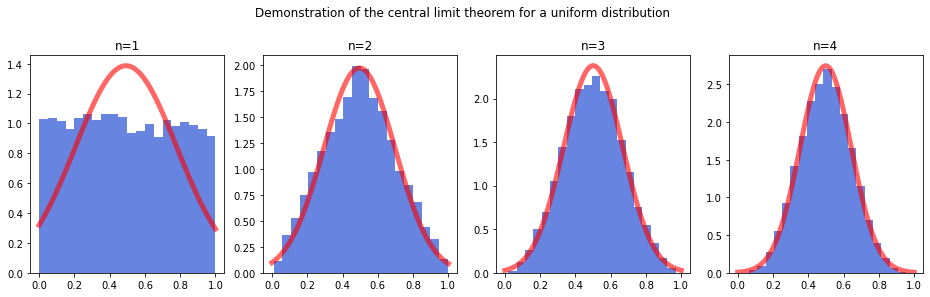

In [27]:
fig, ax = plt.subplots(1, 4, squeeze= True, figsize=(16, 4))
x = np.linspace(0, 1, 100)
for i in range(4):
    f = np.mean(np.random.random((10000, i+1)), axis = 1)
    m, s = np.mean(f), np.std(f, ddof=1)
    fn = (1/(s*np.sqrt(2*np.pi)))*np.exp(-(x-m)**2/(2*s**2))  # normal pdf            
    ax[i].hist(f, 20, density=True, color=[0, 0.2, .8, .6]) 
    ax[i].set_title('n=%d' %(i+1))
    ax[i].plot(x, fn, color=[1, 0, 0, .6], linewidth=5)
plt.suptitle('Demonstration of the central limit theorem for a uniform distribution', y=1.05)
plt.show()

### 17. Estimation

An important aspect when working with statistical data is being able to use estimates to approximate the values of unknown parameters of the dataset. 


**Definition:** *Estimation* is the process of inferring the parameters (e.g. mean) of a distribution from a statistic of samples drown from a population.


Some common estimators are:

- Sample mean $\bar{x}$  for population mean $\mu$
- Sample variance $s$  for population variance $\sigma^2$
- Standard score



### 18. Sampling Distribution of Point Estimates

The most intuitive way to go about giving a value for the estimate is to simply take the **sample
mean**. The sample mean is a point estimate of the population mean. If we
can only choose one value to estimate the population mean, this is our best
guess.



### 19. Standard Error of the Mean

- Now let's suppose that we have only one sample of the propulation. 

- As discussed before, the mean estimate from that sample may be close, but it will not be exactly equal to our parameter of interest (that can only be computed if we have access to the full population). 

- For this reason it is interesting to measure its variability with respect to the sampling process. To this end we can use the **standard error of the mean**.

- It can be mathematically shown that given $n$ independent observations $\{ x_i \}_{i=1,..,n}$ from a population with a standard deviation $\sigma_x$, the standard deviation of the sample mean $\sigma_{\bar{x}}$, or **standard error** is:

$$SE = \frac{\sigma_{x}}{\sqrt{n}} $$

- This allows **to estimate the standard deviation of the sample mean** even if we cannot perform the simulation process (i.e. because we have no access to the population). 

- Usually, $\sigma_x$ is not known and it is substituted by its empirical estimate (that is sufficiently good of $n>30$ and the population distribution is not skewed):


### 20. Bootstrapping.

- A modern alternative to the traditional approach to statistical inference is
the **bootstrapping method**.

- In the bootstrap, we draw $N$ observations with replacement from the original data to create a bootstrap sample or resample.

- Then, we can calculate the mean for this resample. By repeating this process
a large number of times we can built a good approximation of the mean
sampling distribution



### 21. Bootstraping with Mean

In [ ]:
def meanBootstrap(X, num_samples, num_observations):
    y = [0]*num_samples
    for i in range(num_samples):
        rows = np.random.choice(X.index, num_observations) 
        sample = X.loc[rows]
        y[i] = np.mean(sample)
    return y



**Remarks:**

- **X** = data
- **num_samples** = number of bootstrapped samples
- **num_observations** = number of observations to be extracted each time from the data.
- **y** = the return value of function, which is a list of means from  samples. Here, y can be considerd as a sampling distribution mean


### 22. Bootstraping with Median

In [33]:

def medBootstrap(X, num_samples, num_observations):
    y = [0]*num_samples
    for i in range(num_samples):
        rows = np.random.choice(X.index, num_observations) 
        sample = X.loc[rows]
        y[i] = np.median(sample)
    return y



### 23. Confidence Intervals: Traditional Method.

- A point estimate provides a single plausible value for a parameter. 

- However, as we have seen a point estimate is rarely perfect; usually there is some error in the estimate. That is why we have proposed to use the standard error as a measure of its variability.


- As an alternative, a next logical step would be to provide a **plausible range of values** for the parameter. A plausible range of values for the sample parameter is called a **confidence interval**.

- We will base the definition of confidence interval on two ideas:

   + Our point estimate is the most plausible value of the parameter, so it makes sense to build the confidence interval around the point estimate.

   + The plausability of a range of values can be defined from the sampling distribution of the estimate.

- In order to define an interval, we can make use of a well known result from probability that applies to normal distributions: roughly 95% of the time our estimate will be within 1.96 standard errors of the true mean of the distribution.



In [8]:
#Sample code:

#sample_df 

#z-score = 1.96 for alpha = 5%

#==========point_estimate========
#m = sample_df.mean()

#=========Standard Error ==========

#se = sample_df.std()/math.sqrt(len(sample_df))

#ci = [m - se*zscore, m + se*zscore]

#print ("Confidence interval:", ci)

### 24. Confidence Interval by Bootstrapping Method

This is how we would compute a 95% confidence interval of the sample mean by using bootstrapping:

1. Repeat the following steps a large number $M$ of times: 
    + Draw $N$ observations with replacement from the original data to create a bootstrap sample or resample; 
    + Calculate the mean for the resample.
2. Calculate the **mean** of your $M$ values of the sample statistic. This process gives you a “bootstrapped” estimate of the sample statistic.
3. Calculate the **standard deviation** of your $M$ values of the sample statistic. This process gives you a “bootstrapped” estimate of the **SE** of the sample statistic.
4. Obtain the 2.5th and 97.5th percentiles of your $M$ values values of the sample statistic.


In [9]:
#Sample Code

#distribution_of_means  = meanBootstrap(data, 10000, 100)
#ci = [np.percentile(distribution_of_means, 2.5), np.percentile(distribution_of_means, 97.5)]
#print ("Confidence interval:", ci)

**Remarks**: Real Meaning of Confidence

- The real meaning of "confidence" is not evident and it must be understood from the point of view of the generating process.

- Suppose we take many (infinite) samples from a population and built 95% confidence interval from each sample. Then about 95% of those intervals would contain the actual parameter.

- This can be easily showed by simulating a large number of samples and checking how many intervals contain the true parameter:

### 25. Hypothesis Testing

- To give a measure of variability of our estimates is a way of producing a statistical proposition about the population, but not the only one.

- R.A.Fisher(1890-1962) proposed an alternative, known as **hypothesis testing**, that is based on the concept of **statistical significance**.

- The process of determining the statistical significance of an effect is called **hypothesis testing**. This process starts by simplifying the options into two competing hypotheses:

   + $H_0$: null hypothesis
   
   + $H_a$: alternative hypothesis
   

- We call $H_0$ the **null hypothesis** and it represents a skeptical point of view which we want to test as a researcher. 

- $H_a$ is the **alternative hypothesis** and it represents the other point of view.

- The general rule of hypothesis testing is: We will discard $H_0$ (and hence we will consider $H_a$) if the observed effect is significanly different than the under $H_0$.


### 26. Testing Hypotheses Using P-values.

- An advanced notion of statistical significance was developed by R.A.Fisher in the 1920's when looking for a test to decide whether variation in crop yields were due to some specific intervention or merely randon factors beyond experimental control.

- Fisher first assumed that fertilizer caused no difference (null hypothesis) and then calculated $P$, the probability that an observed yield in a fertilized field would occur if fertilizer had no real effect. This probability is called p-value.

- The p-value is the probability of observing data at least as favorable to the alternative hypothesis as our current data set, if the null hypothesis is true.

- To apply a test of hypotheses to our problem, the first step is to quantify the size of the apparent effect by choosing a test statistic. In our case, the apparent effect is a difference in accident rates, so a natural choice for the test statistic is the difference in means between the two periods:

### 27. How to Perform One-Sample Hypothesis Testing (T-Test)?


One sample hypothesis testing is about testing the hypothesis againts one of your population parameters (say $\mu$). You will be solving the following research question:


**Example Research Question**: Does your data suggest average housing price of your Home State has increaased nowadays as compared with that of 5 years ago (i.e, in 2020)? 

You can use Google, Zillow, or other any websites to get the information of average housing price of your Home State in 2020. If you could not find mean housing price, you can use median price, which is more comon in Real-State Market. Say this price as $\mu_0$.   

For example, $\mu_0 = 265.6k$, that means average housing price of Rhode Island 5 years ago (ie,in 2020) was $265600. 

Your **Null** hypothesis and **Alternative** hypothesis will be the following:

  
$$H_0: \mu = \mu_0$$
$$H_a: \mu > \mu_0$$ 
     
**Your Tasks**: Use python function, called **scipy.stats.ttest_1samp()** to perform  the above hypothesis testing. Interpret your results with various components such as test statistic, p-value etc. Make a conclusion of the hypothesis testing by using P-value in the context of the research question.



In [10]:
#import scipy

#scipy.stats.ttest_1samp(data, popmean, alternative='two-sided')


### 28. How to Perform Two-Samples Hypothesis Testing (T-Test)?

In this step, you will perform two-samples hypothesis testing using python function. 

**Example Research Question**: Is there a significant difference in the current average housing prices between your Home State and the Neighboring State? 



Test the following hypothesis using two sample t-Test in python. You MUST explain all the assumptions that you are going to make during the testing.


  $$H_0: \mu_1 = \mu_2$$
  $$H_a: \mu_1  \neq  \mu_2$$ 
     
where $\mu_1$: mean of the housing prices of your Home State

and $\mu_2$: mean of the housing  prices  of your Neighbouring State


      
**Your Tasks**: Use python function, called  **scipy.stats.ttest_ind()** to perform  the two sample hypothesis testing. Report the key findings from your test results such as T statistic, P-values, etc. Make a conclusion of the hypothesis testing by using P-value in the context of the research question.

In [11]:

import scipy

#Normality test

#scipy.stats.normaltest(data)

## Normality plots(qq-plot) is highly recommended to undertand the results of normality test


#Two-sample t-test

#scipy.stats.ttest_ind(data1, data2, equal_var = False) # it is recommended to check the variances of two data sets
